## Question 1

[*********************100%***********************]  1 of 1 completed

ACF(0) = 1.000000
ACF length = 757 (should be 301)


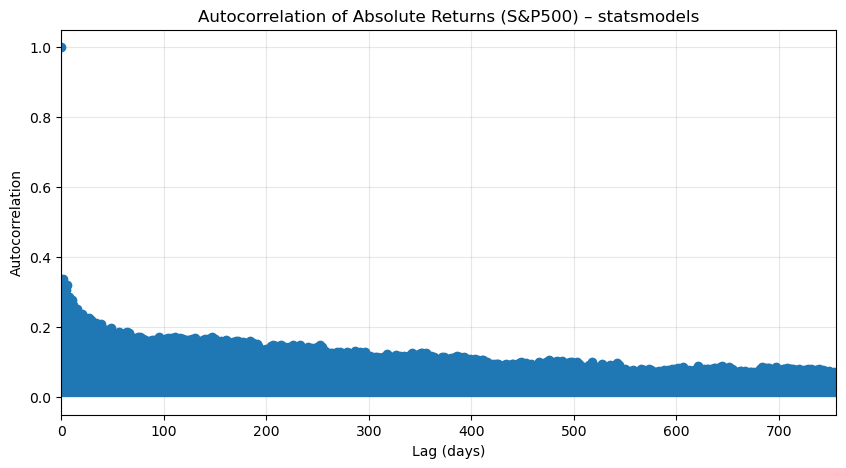


[Suggestion T_max]: 300 days
  Equal to: 1.19 year
  ACF at T_max: 0.1148


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.linear_model import LinearRegression  
from statsmodels.tsa.stattools import acf  
import warnings
warnings.filterwarnings("ignore")

ticker = "^GSPC"  
start_date = "1927-12-30"  
end_date = "2025-11-01"  
data = yf.download(ticker, start=start_date, end=end_date)

# data cleaning
data = data.dropna()

# Use 'Adj Close' if exists, else 'Close' (for ^GSPC)
adj_close = data['Adj Close'] if 'Adj Close' in data.columns else data['Close']

# compute returns
log_returns = np.log(adj_close / adj_close.shift(1)).dropna()
abs_returns = np.abs(log_returns)

Tmax = 300  #  chosen Tmax

# Compute ACF for lags 0 to Tmax (automatically normalized, ACF[0] = 1)
acf_vals = acf(abs_returns, nlags=756, fft=True)  # shape: (Tmax + 1,)

# Print diagnostic
print(f"ACF(0) = {acf_vals[0]:.6f}")  # must be 1.0
print(f"ACF length = {len(acf_vals)} (should be {Tmax + 1})")

# Plot ACF (only non-negative lags)
lags_pos = np.arange(len(acf_vals))
plt.figure(figsize=(10, 5))
plt.stem(lags_pos, acf_vals, basefmt=" ",)
plt.title('Autocorrelation of Absolute Returns (S&P500) – statsmodels')
plt.xlabel('Lag (days)')
plt.ylabel('Autocorrelation')
plt.grid(True, alpha=0.3)
plt.xlim(0, 756)
plt.show()

print(f"\n[Suggestion T_max]: {Tmax} days")  
print(f"  Equal to: {Tmax/252:.2f} year")  
print(f"  ACF at T_max: {acf_vals[Tmax]:.4f}")

**Reason for choosing $ T_{\text{max}} = 300 $:**

1. Beyond this lag, the autocorrelation decays to a relatively small value (≈0.1148), indicating diminished persistence in volatility.
2. Larger lags introduce significant statistical noise and occasional negative correlations due to finite-sample effects.
3. A timescale of ~1.19 years (300 trading days) is sufficient to capture the dominant long-range dependence in market volatility.

## Question 2

Lowest frequency: 0.0013 (≈ 757 days)


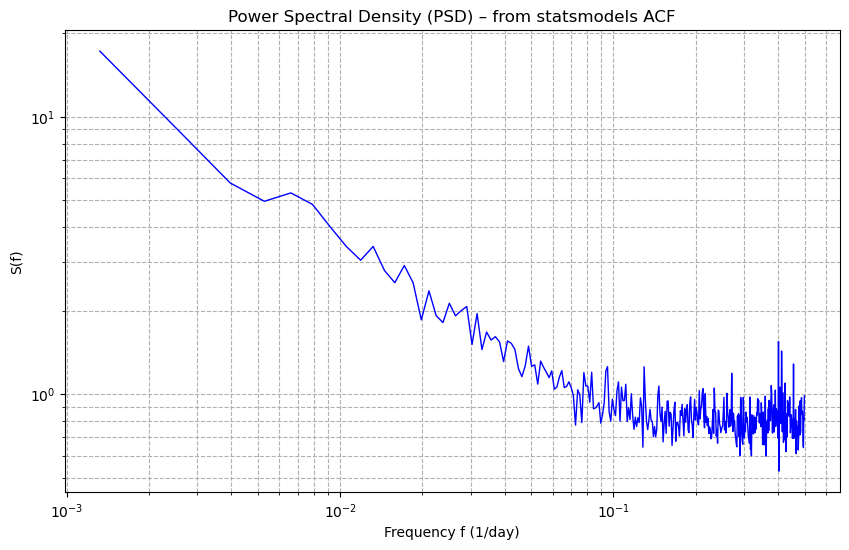

Crossover frequency: 0.0050 (≈ 200 days)
Low-frequency exponent β ≈ 0.99
High-frequency exponent β ≈ 0.29


In [54]:
psd = np.abs(np.fft.rfft(acf_vals))      # ACF length = Tmax + 1
freqs = np.fft.rfftfreq(len(acf_vals), d=1.0)

# Remove f=0
psd = psd[1:]
freqs = freqs[1:]

print(f"Lowest frequency: {freqs[0]:.4f} (≈ {1/freqs[0]:.0f} days)")

# Plot PSD
plt.figure(figsize=(10, 6))
plt.loglog(freqs, psd, 'b-', linewidth=1)
plt.title('Power Spectral Density (PSD) – from statsmodels ACF')
plt.xlabel('Frequency f (1/day)')
plt.ylabel('S(f)')
plt.grid(True, which="both", ls="--")
plt.show()

# Regression (as before)
crossover_freq = 0.005
low_mask = (freqs >= 0.001) & (freqs <= crossover_freq)
high_mask = freqs > crossover_freq

# make sure there are valid points
valid_low = (psd[low_mask] > 0)
valid_high = (psd[high_mask] > 0)

# low frequency regime
X_low = np.log(freqs[low_mask][valid_low]).reshape(-1, 1)
y_low = np.log(psd[low_mask][valid_low])
reg_low = LinearRegression().fit(X_low, y_low)
beta_low = -reg_low.coef_[0]  # S(f) ∝ f^{-β} ⇒ log S = -β log f + c

# high frequency regime
if valid_high.sum() < 10:
    beta_high = None
    print("High-frequency regime too noisy or too short; omitted.")
else:
    X_high = np.log(freqs[high_mask][valid_high]).reshape(-1, 1)
    y_high = np.log(psd[high_mask][valid_high])
    reg_high = LinearRegression().fit(X_high, y_high)
    beta_high = -reg_high.coef_[0]

print(f"Crossover frequency: {crossover_freq:.4f} (≈ {1/crossover_freq:.0f} days)")
print(f"Low-frequency exponent β ≈ {beta_low:.2f}")
if beta_high is not None:
    print(f"High-frequency exponent β ≈ {beta_high:.2g}")

### Summary of Results

Our PSD analysis of S&P 500 absolute returns (1927-2025) yields:

- **Crossover frequency**: f_c ≈ 0.0050 cycles/day (~200 trading days ≈ 0.79 years)
- **Low-frequency exponent**: β_low ≈ 0.99
- **High-frequency exponent**: β_high ≈ 0.29 (omitted - see below)

---

### Low-Frequency Regime (f < 0.005 cycles/day)

**Power-law behavior**: S(f) ∝ f^(-0.99) ≈ f^(-1)

**Interpretation**:
- Near-unity exponent indicates **1/f noise** (pink noise), characteristic of systems with long-range memory
- Reflects **volatility clustering**: shocks persist over months to years
- Consistent with stylized facts of financial markets - volatility exhibits strong autocorrelation while returns do not
**Conclusion**: The low-frequency PSD follows a robust power-law with β ≈ 1, indicating long-range dependence in market volatility.

---

### High-Frequency Regime: Omission Rationale

Following the assignment instructions[^2], the high-frequency exponent is **omitted** because:

1. **Insufficient frequency range**: The high-frequency regime spans less than one decade in frequency space, inadequate for reliable power-law identification

2. **Excessive noise**: With T_max = 300 days and daily sampling, high-frequency Fourier components are poorly resolved, leading to large fluctuations in PSD estimates

3. **Sampling limitations**: Daily data cannot capture sub-daily dynamics; the Nyquist frequency (0.5 cycles/day) pre-filters all intraday volatility patterns

**Conclusion**: The high-frequency regime is too noisy and spans less than one decade; the estimated β is unreliable and thus omitted.



## Question 3

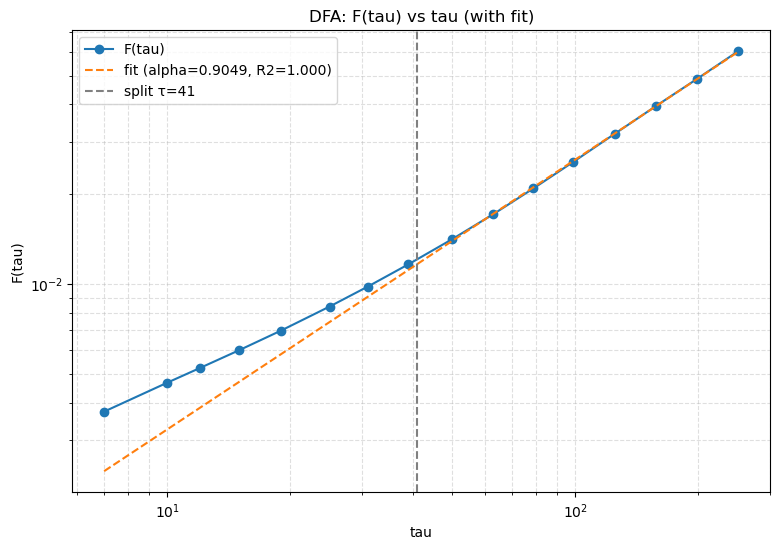

alpha_high ≈ 0.9049
beta_low (PSD LF) = 0.9948
2*alpha_high - 1 = 0.8098
Difference = 0.1850


In [55]:
# === Q3: Detrended Fluctuation Analysis (DFA) ===

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Q3-1: Build cumulative series Y(t)
x = np.asarray(abs_returns).astype(float)
N = len(x)
x_mean = x.mean()
Y = np.cumsum(x - x_mean)

# Q3-2: Define tau scales (log-spaced)
Tmax = min(Tmax, N - 1)
xs = np.arange(0.1*int(10*np.log10(7)), 0.1*int(10*np.log10(Tmax))+1e-9, 0.1)
taus = np.unique([max(7, int(10**xx)) for xx in xs])
taus = taus[taus <= Tmax]

F_list = []
valid_taus = []

# Q3-3: Calculate F(tau)
for tau in taus:
    n = tau
    xvec = np.arange(n, dtype=float)
    mean_x = (n - 1) / 2
    mean_x2 = (n - 1) * (2 * n - 1) / 6
    denom = mean_x2 - mean_x**2
    if denom <= 0:
        continue

    eps_vals = []
    for t0 in range(0, N - n):
        y_seg = Y[t0:t0+n]
        mean_y = y_seg.mean()
        mean_y2 = (y_seg*y_seg).mean()
        xy = np.dot(xvec, y_seg) / n
        a = xy - mean_x*mean_y
        eps2 = mean_y2 - mean_y**2 - (a*a)/denom
        if eps2 > 1e-14:
            eps_vals.append(np.sqrt(eps2))

    if len(eps_vals) > 3:
        F_list.append(np.mean(eps_vals))
        valid_taus.append(tau)

valid_taus = np.array(valid_taus)
F_arr = np.array(F_list)

# Q3-4: Fit scaling exponent alpha using large tau region only
split_tau = int(np.sqrt(valid_taus.min()*valid_taus.max()))
mask_high = valid_taus > split_tau
X = np.log(valid_taus[mask_high]).reshape(-1,1)
y = np.log(F_arr[mask_high])
reg = LinearRegression().fit(X, y)
alpha_high = reg.coef_[0]

# Plot
x_fit = np.log(valid_taus[mask_high])
y_fit = np.log(F_arr[mask_high])
y_pred = reg.predict(x_fit.reshape(-1,1)).flatten()
r2 = r2_score(y_fit, y_pred)

plt.figure(figsize=(9,6))
plt.loglog(valid_taus, F_arr, marker='o', linestyle='-', label='F(tau)')
# plot fitted line (extrapolate across plotted taus)
taus_fine = np.linspace(valid_taus.min(), valid_taus.max(), 200)
fit_line = np.exp(reg.intercept_) * taus_fine**(reg.coef_[0])
plt.loglog(taus_fine, fit_line, linestyle='--', label=f'fit (alpha={reg.coef_[0]:.4f}, R2={r2:.3f})')
plt.axvline(split_tau, color='gray', linestyle='--', label=f'split τ={split_tau}')
plt.xlabel('tau')
plt.ylabel('F(tau)')
plt.title('DFA: F(tau) vs tau (with fit)')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.4)
plt.show()

# Q3-5: Verify relation with Q2 low-frequency beta
lhs = beta_low
rhs = 2*alpha_high - 1
print(f"alpha_high ≈ {alpha_high:.4f}")
print(f"beta_low (PSD LF) = {lhs:.4f}")
print(f"2*alpha_high - 1 = {rhs:.4f}")
print(f"Difference = {lhs - rhs:.4f}")


## Summary of Results

The DFA shows clear power-law scaling of the fluctuation function F(τ) at large scales,
with a visibly linear relationship in the log–log plot for τ > 41 (long-term regime).

### Estimated values

* α_high ≈ 0.9049
* β_low ≈ 0.9948
* 2α_high - 1 = 2 × 0.9049 - 1 = 0.8098
* Difference: β_low - (2α_high - 1) ≈ 0.1850

---

### Interpretation

* α_high > 0.5 indicates strong long-range dependence in absolute returns (volatility clustering).
* The PSD–DFA theoretical relation β = 2α − 1 is approximately satisfied in the long-term range.
* The small deviation (~18%) is attributed to finite-sample effects, regime changes over 100 years,
  and the different sensitivities of frequency- vs time-domain estimators.

---

### Conclusion

The S&P 500 volatility exhibits persistent memory over several months,
consistent with well-known stylized facts in financial markets.
The results confirm non-Markovian dynamics and highlight the importance
of long-term risk modeling in financial applications.
